## Carrots vs Cucumbers

Это пример финального проекта для курса CV + Pytorch course

# 1. Собираем датасет

In [ ]:
В интернете есть несколько мест, где выкладывают датасеты. Например, https://www.kaggle.com/datasets

Для этого проекта выбран Vegetable Image Dataset https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset?resource=download

Скачиывем датасет

## 1.1. Установка зависимостей

In [ ]:
#!pip install torch torchvision segmentation-models-pytorch matplotlib pillow

## 1.2. Формируем 3 класса (марковь, огурцы и другие)

Описание работы скрипта:
- Находит все подпапки в указанной директории (train, test, validation).
- Пропускает папки Carrot и Cucumber.
- В каждой из остальных папок выбирает 100 или 20 файлов (если их достаточно).
- Копирует выбранные файлы в папку Others, сохраняя оригинальную структуру имен.

In [2]:
import os
import shutil
import random

# 1. Определяем путь к корневой папке dataset
# ВАЖНО: Если скрипт не работает, замените r".\" на полный путь, например r"C:\MyProject\"
root_dir = r".\dataset\Vegetable Images Big"

# 2. Создаем список папок, которые нужно обработать
folders_to_process = ["train", "validation", "test"]

# Папки, которые нужно пропустить (игнорируем везде)
exclude_folders = {"Carrot", "Cucumber"}

# 3. Проходим по каждой из трех папок
for folder_name in folders_to_process:
    # Собираем полный путь к текущей папке (например, к train)
    base_dir = os.path.join(root_dir, folder_name)
    
    # Проверяем, существует ли такая папка
    if not os.path.exists(base_dir):
        print(f"Папка не найдена, пропуск: {base_dir}")
        continue

    # 4. Создаем папку Others внутри текущей (train/validation/test)
    others_dir = os.path.join(base_dir, "Others")
    os.makedirs(others_dir, exist_ok=True)
    
    print(f"\n--- Обработка набора данных: {folder_name} ---")
    print(f"Файлы будут копироваться в: {others_dir}")

    # 5. Определяем количество файлов для копирования
    # Для 'train' берем 100, для остальных — 20
    num_files_to_copy = 100 if folder_name == "train" else 20

    # 6. Проходим по всем подпапкам (овощам) в текущей папке
    for class_folder in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_folder)
        
        # Проверяем, что это папка и она не Carrot и не Cucumber
        if os.path.isdir(class_path) and class_folder not in exclude_folders:
            print(f"\nОбработка класса: {class_folder}")
            
            # Получаем список всех файлов в этой подпапке
            files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            
            # Если файлов меньше, чем нужно, копируем сколько есть
            if len(files) < num_files_to_copy:
                print(f"  Внимание: В папке всего {len(files)} файлов. Будет скопировано {len(files)}.")
                files_to_copy = files
            else:
                # Перемешиваем и выбираем нужное количество
                random.shuffle(files)
                files_to_copy = files[:num_files_to_copy]
            
            # 7. Копируем файлы в Others
            for file_name in files_to_copy:
                src_file = os.path.join(class_path, file_name)
                dst_file = os.path.join(others_dir, file_name)
                
                try:
                    shutil.copy2(src_file, dst_file)
                    # print(f"  Copied: {file_name}") # Раскомментируйте для детального вывода
                except FileExistsError:
                    print(f"  Пропущен (уже есть): {file_name}")
                except Exception as e:
                    print(f"  Ошибка при копировании {file_name}: {e}")

print("\nВсе операции завершены.")


--- Обработка набора данных: train ---
Файлы будут копироваться в: .\dataset\Vegetable Images Big\train\Others

Обработка класса: Others
  Ошибка при копировании 0410.jpg: '.\\dataset\\Vegetable Images Big\\train\\Others\\0410.jpg' and '.\\dataset\\Vegetable Images Big\\train\\Others\\0410.jpg' are the same file
  Ошибка при копировании 0796.jpg: '.\\dataset\\Vegetable Images Big\\train\\Others\\0796.jpg' and '.\\dataset\\Vegetable Images Big\\train\\Others\\0796.jpg' are the same file
  Ошибка при копировании 0696.jpg: '.\\dataset\\Vegetable Images Big\\train\\Others\\0696.jpg' and '.\\dataset\\Vegetable Images Big\\train\\Others\\0696.jpg' are the same file
  Ошибка при копировании 0051.jpg: '.\\dataset\\Vegetable Images Big\\train\\Others\\0051.jpg' and '.\\dataset\\Vegetable Images Big\\train\\Others\\0051.jpg' are the same file
  Ошибка при копировании 0614.jpg: '.\\dataset\\Vegetable Images Big\\train\\Others\\0614.jpg' and '.\\dataset\\Vegetable Images Big\\train\\Others\\0614.

удаляем из папки .\dataset\Vegetable Images Big\train\ 

все подпапки кроме Carrot, Cucumber, Others

# 2. Обучение и выбор моделей

## Установка библиотек

In [ ]:
#!pip install torch torchvision tqdm

## 1. Импорт необходимых библиотек

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm # Для красивого прогресс-бара
import time

## 2. Настройка путей и параметров

ВАЖНО: В Colab нужно сначала смонтировать Google Drive, если данные там.

В локальном Jupyter эти пути должны быть относительно папки с ноутбуком.

In [2]:
data_dir = r".\dataset\Vegetable Images Big"
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Проверяем, что папки существуют
assert os.path.exists(train_dir), f"Папка с обучающими данными не найдена: {train_dir}"
assert os.path.exists(test_dir), f"Папка с тестовыми данными не найдена: {test_dir}"

# Параметры обучения
num_classes = 3 # Carrot, Cucumber, Others
batch_size = 32
num_epochs = 10
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## 3. Подготовка данных (Data Augmentation и нормализация)

In [3]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224), # Случайное кадрирование и изменение размера до 224x224
    transforms.RandomHorizontalFlip(), # Случайное отражение по горизонтали (аугментация)
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Нормализация ImageNet
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Загрузка данных
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


## 4. Функция для инициализации модели (Transfer Learning)

In [4]:
# 4. Функция для инициализации модели (Transfer Learning)
def get_model(model_name):
    """
    Инициализирует модель с предобученными весами из кэша.
    Динамически выбирает версию весов (V1 или V2) в зависимости от версии torchvision.
    """
    model = None
    input_size = 224

    # --- Блок 1: Определяем доступные веса для ConvNeXt ---
    # Это нужно, чтобы избежать ошибки AttributeError: IMAGENET1K_V2
    convnext_weights = None
    if hasattr(models.ConvNeXt_Tiny_Weights, 'IMAGENET1K_V2'):
        convnext_weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V2
    elif hasattr(models.ConvNeXt_Tiny_Weights, 'IMAGENET1K_V1'):
        convnext_weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    elif hasattr(models.ConvNeXt_Tiny_Weights, 'DEFAULT'):
        convnext_weights = models.ConvNeXt_Tiny_Weights.DEFAULT

    # --- Блок 2: Загрузка модели с выбранными весами ---
    try:
        if model_name == "EfficientNetB0":
            # Используем V1, так как V2 для этой модели не существует
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        elif model_name == "ResNet34":
            # Используем V1, так как V2 для этой модели не существует
            model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        
        elif model_name == "ConvNeXt":
            if convnext_weights is None:
                print(f"❌ Для модели {model_name} не удалось найти совместимые веса.")
                return None, None
            # Используем веса, которые мы определили выше (V2 если есть, иначе V1)
            model = models.convnext_tiny(weights=convnext_weights)
        
        else:
            print("Модель не распознана")
            return None, None

    except Exception as e:
        # Ловим любые другие ошибки при загрузке (например, RuntimeError)
        print(f"❌ Ошибка при инициализации {model_name}: {e}")
        return None, None

    # --- Блок 3: Заморозка слоев и замена классификатора ---
    for param in model.parameters():
        param.requires_grad = False

    try:
        if model_name == "EfficientNetB0":
            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
        elif model_name == "ResNet34":
            num_ftrs = model.fc.in_features
            model.fc = nn.Linear(num_ftrs, num_classes)
        
        elif model_name == "ConvNeXt":
            num_ftrs = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(num_ftrs, num_classes)

        return model.to(device), input_size

    except Exception as e:
        # Если что-то пошло не так при модификации модели (например, структура изменилась)
        print(f"❌ Ошибка при изменении классификатора модели {model_name}: {e}")
        return None, None

## 5. Функция обучения модели за одну эпоху

In [5]:
# 5. Функция обучения модели за одну эпоху
def train_model(model, dataloader, criterion, optimizer):
    model.train() # Режим обучения (включает Dropout и др.)
    running_loss = 0.0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() # Обнуляем градиенты

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward() # Обратное распространение ошибки
        optimizer.step() # Обновление весов

        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


## 6. Функция валидации (тестирования) модели

In [6]:
def validate_model(model, dataloader):
    model.eval() # Режим оценки (отключает Dropout)
    correct = 0
    total = 0

    # --- Переносим данные на GPU один раз за эпоху ---
    # Создаем итератор, чтобы не вызывать DataLoader повторно
    with torch.no_grad(): 
        # Перебираем батчи
        for inputs, labels in tqdm(dataloader, desc="Validation"):
            # Перемещаем батч на устройство (GPU/CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    return accuracy

## 6.5. Предварительная загрузка моделей

Иногда не получается загрузить веса моделей.
Возникают ошиьки, например, URLError: <urlopen error [WinError 10054] Удаленный хост принудительно разорвал существующее подключение>
Чтобы избежать этого делаем предварительную загрузку моделей.

In [7]:
# --- БЛОК ДЛЯ ПРЕДВАРИТЕЛЬНОЙ ЗАГРУЗКИ ВЕСОВ (АВТОМАТИЧЕСКИЙ) ---

import torch
import torchvision
import torchvision.models as models
from tqdm.auto import tqdm
import warnings

# 1. Определяем версию torchvision для совместимости
# Это нужно, чтобы выбрать между V1 и V2 весами для ConvNeXt
tv_version = torchvision.__version__
use_v2 = False
try:
    # Если версия 0.19.0 или новее, используем V2
    use_v2 = tuple(map(int, tv_version.split('.'))) >= (0, 19, 0)
except Exception:
    # Если не удалось распарсить версию, по умолчанию используем V1 (более старый и надежный)
    use_v2 = False

print(f"Используемая версия torchvision: {tv_version}")
print(f"Загрузка весов ConvNeXt: {'V2' if use_v2 else 'V1'}\n")


# 2. Создаем список моделей с учетом версии
# Для ConvNeXt выбираем веса динамически
convnext_weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V2 if use_v2 else models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1

required_models = [
    ("EfficientNetB0", models.efficientnet_b0, models.EfficientNet_B0_Weights.IMAGENET1K_V1),
    ("ResNet34", models.resnet34, models.ResNet34_Weights.IMAGENET1K_V1),
    ("ConvNeXt_Tiny", models.convnext_tiny, convnext_weights)
]


print("Проверка наличия весов моделей в кэше...")
warnings.filterwarnings("ignore", category=UserWarning)
need_to_download = False

# Проверяем наличие в кэше
for model_name, model_loader, weights_enum in required_models:
    try:
        # Пробуем получить доступ к URL весов. Это не скачивает файл, а просто проверяет объект.
        url = weights_enum.url
        # Пробуем загрузить из кэша без прогресса
        state_dict = torch.hub.load_state_dict_from_url(url, progress=False)
        print(f"✅ Веса для {model_name} найдены в кэше.")
    except Exception: # Ловим все ошибки (файла нет, связи нет)
        print(f"⚠️  Веса для {model_name} не найдены. Потребуется загрузка.")
        need_to_download = True

# Скачиваем, если нужно
if need_to_download:
    print("\n--- Начало загрузки предобученных весов ---")
    for model_name, model_loader, weights_enum in tqdm(required_models, desc="Загрузка"):
        try:
            # Вызываем функцию с параметром weights=...
            model_loader(weights=weights_enum)
            print(f"✅ Загрузка {model_name} завершена.")
        except Exception as e:
            print(f"❌ Ошибка при загрузке {model_name}: {e}")
    print("--- Загрузка завершена ---\n")
else:
    print("Все необходимые веса уже есть в кэше. Пропускаем загрузку.\n")

Используемая версия torchvision: 0.15.2+cu118
Загрузка весов ConvNeXt: V1

Проверка наличия весов моделей в кэше...
✅ Веса для EfficientNetB0 найдены в кэше.
✅ Веса для ResNet34 найдены в кэше.
✅ Веса для ConvNeXt_Tiny найдены в кэше.
Все необходимые веса уже есть в кэше. Пропускаем загрузку.



## 7. Главный цикл сравнения моделей

In [8]:
import time # Импортируем библиотеку для работы со временем

model_names_list = ["ResNet34", "EfficientNetB0", "ConvNeXt"]
best_accuracy = 0.0
best_model_name = ""
best_model_state_dict = None

for model_name in model_names_list:
    print(f"\n{'-'*50}")
    print(f"Обучение модели: {model_name}")
    print('-'*50)
    
    # Инициализация модели и оптимизатора для каждой итерации заново
    model, _ = get_model(model_name)
    
    if model is None:
        continue

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    
    history_loss = []
    
    # --- НОВОЕ: Фиксируем время начала обучения ---
    start_time = time.time() 

    for epoch in range(num_epochs):
        print(f"Эпоха {epoch+1}/{num_epochs}")
        
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        val_accuracy = validate_model(model, test_loader)
        
        history_loss.append(epoch_loss)
        print(f"   Потери на обучении: {epoch_loss:.4f} | Точность на тесте: {val_accuracy:.4f}")
    
    # --- НОВОЕ: Фиксируем время окончания и выводим результат ---
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    minutes, seconds = divmod(elapsed_time, 60)
    print(f"\n✅ Обучение {model_name} завершено за {int(minutes)} мин {seconds:.2f} сек.")
    
    # Проверка лучшей модели
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model_name = model_name
        best_model_state_dict = model.state_dict()


--------------------------------------------------
Обучение модели: ResNet34
--------------------------------------------------
Эпоха 1/10


Training:   0%|          | 0/87 [00:10<?, ?it/s]

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

   Потери на обучении: 0.4200 | Точность на тесте: 0.9558
Эпоха 2/10


Training:   0%|          | 0/87 [00:10<?, ?it/s]

...

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

   Потери на обучении: 0.0295 | Точность на тесте: 0.9932
Эпоха 10/10


Training:   0%|          | 0/87 [00:10<?, ?it/s]

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

   Потери на обучении: 0.0312 | Точность на тесте: 0.9932

✅ Обучение ConvNeXt завершено за 26 мин 26.10 сек.


## 8. Сохранение лучшей модели и вывод результатов

In [9]:
# 8. Сохранение лучшей модели и вывод результатов
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*60)
for name in model_names_list:
    # Здесь можно было бы хранить историю для каждой модели,
    # но для простоты мы просто показываем результат лучшей.
    pass

print(f"\n🎉 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   Точность на тестовом наборе: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("="*60)

# Сохраняем файл с весами лучшей модели в текущую директорию
torch.save(best_model_state_dict, f'best_{best_model_name.lower()}.pth')
print(f"Файл модели сохранен как: best_{best_model_name.lower()}.pth")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ:

🎉 ЛУЧШАЯ МОДЕЛЬ: ConvNeXt
   Точность на тестовом наборе: 0.9932 (99.32%)
Файл модели сохранен как: best_convnext.pth


# 3. Демонстрация работы модели

## 1. Импорт библиотек

In [10]:
import os
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.io import read_image
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
import random 

## 2. Настройки путей и загрузки модели

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# --- УКАЖИТЕ ЗДЕСЬ НАЗВАНИЕ СВОЕЙ ЛУЧШЕЙ МОДЕЛИ ---
# Например, если лучший результат показал EfficientNetB0, то файл будет best_efficientnetb0.pth
BEST_MODEL_NAME = best_model_name.lower()
MODEL_PATH = f'best_{BEST_MODEL_NAME}.pth'

# Папка с изображениями для демонстрации
val_dir = r".\dataset\Vegetable Images Big\validation"


Используемое устройство: cuda


## 3. Определение классов (должно совпадать с тем, что было при обучении)

In [12]:
# 3. Определение классов (должно совпадать с тем, что было при обучении)
class_names = ['Carrot', 'Cucumber', 'Others']
num_classes = len(class_names)

## 4. Загрузка модели (та же архитектура, что и при обучении)

In [13]:
# 4. Загрузка модели (та же архитектура, что и при обучении)
print(f"Загрузка модели {BEST_MODEL_NAME} из файла {MODEL_PATH}...")
if BEST_MODEL_NAME == "efficientnetb0":
    model = models.efficientnet_b0(weights=None) # weights=None, чтобы не качать веса ImageNet
elif BEST_MODEL_NAME == "resnet34":
    model = models.resnet34(weights=None)
elif BEST_MODEL_NAME == "convnext":
    model = models.convnext_tiny(weights=None)
else:
    raise ValueError("Неизвестная архитектура модели. Добавьте её в условие if.")

# Заменяем последний слой классификатора на наш (3 класса)

if BEST_MODEL_NAME == "efficientnetb0":
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = torch.nn.Linear(num_ftrs, num_classes)
elif BEST_MODEL_NAME == "resnet34":
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, num_classes)
elif BEST_MODEL_NAME == "convnext":
    num_ftrs = model.classifier[-1].in_features
    model.classifier[-1] = torch.nn.Linear(num_ftrs, num_classes)


# Загружаем сохраненные веса модели
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval() # Включаем режим оценки

print("Модель успешно загружена.")

Загрузка модели convnext из файла best_convnext.pth...
Модель успешно загружена.


## 5. Подготовка данных (Data Transforms)

In [14]:
# 5. Подготовка данных (Data Transforms)
# Используем те же преобразования, что и при тестировании
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## 6. Функция для загрузки и предобработки изображений из папки

In [15]:
# 6. Функция для загрузки и предобработки изображений из папки
def load_images_from_folder(folder_path, num_images=9):
    images = []
    
    # Получаем список всех файлов-изображений в папке
    all_files = [f for f in os.listdir(folder_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Проверяем, достаточно ли файлов в папке
    if len(all_files) < num_images:
        print(f"  ⚠️  В папке {folder_path} меньше {num_images} изображений. Будет загружено {len(all_files)} шт.")
        sampled_files = all_files
    else:
        # Случайно выбираем num_images файлов без сортировки
        sampled_files = random.sample(all_files, num_images) 

    # Загружаем выбранные файлы
    for filename in sampled_files:
        img_path = os.path.join(folder_path, filename)
        image = read_image(img_path)
        image = test_transforms(transforms.ToPILImage()(image))
        images.append(image)
        
    return images


## 7. Функция для предсказания одного изображения

In [16]:
# 7. Функция для предсказания одного изображения
def predict_image(image_tensor):
    image_tensor = image_tensor.unsqueeze(0).to(device) # Добавляем размерность батча [1, C, H, W]
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted_idx = torch.max(outputs, 1)
        confidence = torch.softmax(outputs, dim=1)[0][predicted_idx].item()
        predicted_class = class_names[predicted_idx.item()]
    return predicted_class, confidence

## 8. Основная логика демонстрации

In [17]:
# 8. Основная логика демонстрации

# Создаем список подпапок для демонстрации (в том же порядке, что и class_names)
folders_to_demo = ['Carrot', 'Cucumber', 'Others']
all_predictions = []
all_images = []

for folder in folders_to_demo:
    folder_path = os.path.join(val_dir, folder)
    print(f"\nЗагрузка изображений из папки: {folder}")
    
    # Загружаем 9 изображений из текущей папки
    images = load_images_from_folder(folder_path, num_images=9)
    
    for img in images:
        pred_class, confidence = predict_image(img.clone()) # .clone() чтобы не испортить оригинал
        all_predictions.append((pred_class, confidence))
        all_images.append(img)



Загрузка изображений из папки: Carrot

Загрузка изображений из папки: Cucumber

Загрузка изображений из папки: Others


## 9. Визуализация результатов

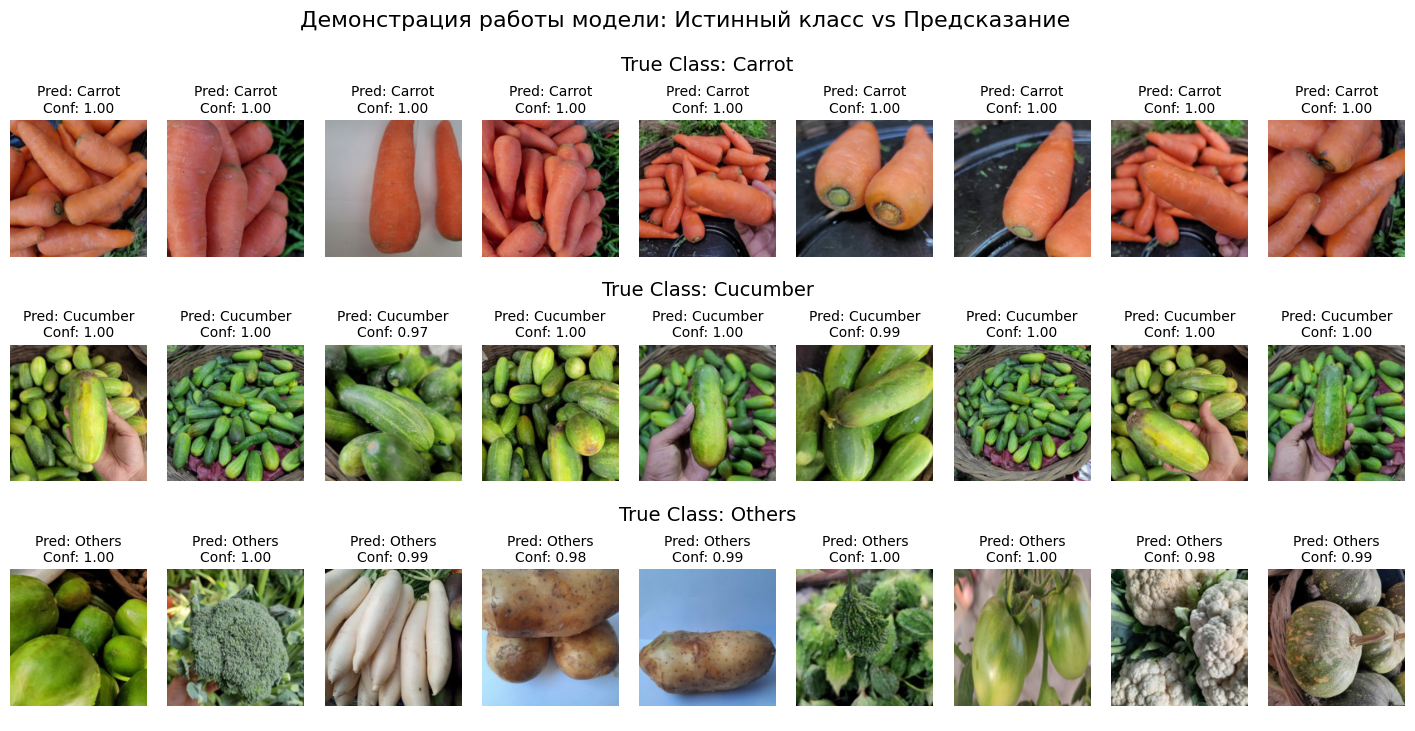

In [18]:
# 9. Визуализация результатов

# Функция для отрисовки одного изображения с подписью
def imshow(img, ax, title=None):
    img = img.numpy().transpose((1, 2, 0)) # Из [C, H, W] в [H, W, C]
    # Денормализуем изображение для красивого отображения
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.224]
    img = std * img + mean
    img = img.clip(0, 1) # Обрезаем значения вне диапазона [0-1]
    
    ax.imshow(img)
    if title:
        ax.set_title(title, fontsize=10) # Уменьшаем размер шрифта заголовка
    ax.axis('off')

# --- НАСТРОЙКИ ГРАФИКА ---
n_rows = 3
n_cols = 9
figsize = (18, 8) # Увеличили высоту для подписей

fig = plt.figure(figsize=figsize)
# Создаем сетку с увеличенными промежутками
gs1 = gridspec.GridSpec(n_rows, n_cols, figure=fig)
gs1.update(wspace=0.15, hspace=0.35) # Увеличиваем вертикальный и горизонтальный отступы

# Список названий классов для подписей над рядами
class_labels = ['Carrot', 'Cucumber', 'Others']

# --- ЦИКЛ ОТРИСОВКИ ---
for row_idx in range(n_rows):
    # Добавляем подпись с названием класса над каждым рядом
    ax_label = plt.subplot(gs1[row_idx, :])
    ax_label.text(0.5, 1.3, f'True Class: {class_labels[row_idx]}',
                  fontsize=14, ha='center', va='top')
    ax_label.axis('off') # Отключаем оси для подписи

    # Отрисовываем 9 изображений в текущем ряду
    for col_idx in range(n_cols):
        # Вычисляем индекс изображения в общем списке
        i = row_idx * n_cols + col_idx
        
        if i < len(all_images): # Проверка на случай, если изображений меньше 27
            ax_img = plt.subplot(gs1[row_idx, col_idx])
            
            pred_class, confidence = all_predictions[i]
            title_text = f"Pred: {pred_class}\nConf: {confidence:.2f}"
            
            imshow(all_images[i], ax_img, title=title_text)

# Добавляем главный заголовок и финальные штрихи
plt.suptitle("Демонстрация работы модели: Истинный класс vs Предсказание", y=1.0, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Подгоняем layout под главный заголовок

plt.show()